In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# MLPClassifier

The MLPClassifier contains several functions that are used for training, testing, and evaluation. It is made up of three MLP models, as well as the fit, predict, evaluate, and grid_search_MLP functions.


## Model Architecture (3 MLP models)

The class contains three MLP models: small (3 layers), medium (4 layers), and large (5 layers). All the models are very similar to each other. The small model is the medium model with the first layer removed, and the medium model is the large model with the first layer removed. Each model consists of a sequence of linear layers with ReLU activation functions. The models also include batch normalization and dropout (0.4) in each layer except the last two layers. Batch normalization is included to stabilize training, and dropout is used to reduce overfitting. The final layer produces outputs equal to the number of classes. This design structure allows us to test different MLP models with varying numbers of layers.

- Small MLP:
Flatten input_dim → Linear(input_dim→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

- Medium MLP:
Flatten input_dim → Linear(input_dim→256) → ReLU → BatchNorm1d(256) → Dropout(0.4) → Linear(256→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

- Large MLP:
Flatten input_dim → Linear(input_dim→512) → ReLU → BatchNorm1d(512) → Dropout(0.4) → Linear(512→256) → ReLU → BatchNorm1d(256) → Dropout(0.4) → Linear(256→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

## Fit Function

The fit function handles all the training. Models were trained using the Adam optimizer with weight decay for regularization. The loss function used was Cross-Entropy Loss with label smoothing, which helps improve generalization.

Training was performed in mini-batches using PyTorch. During each epoch, the model was first trained on the training set, and then its performance was evaluated on the validation set. Validation accuracy was used as the main metric for model selection.

To ensure that the best-performing model was preserved, the weights corresponding to the highest validation accuracy were saved during training and reloaded at the end.

## Predict Function

Produces the outputs and selects the prediction with the highest probability.



## Evaluate Function

Uses the true values and predicted values to evaluate accuracy.

## Grid_search_mlp function

It performs hyperparameter tuning. It receives all the parameters for training and returns the best model among all the models.

In [3]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, size="small"):
        super().__init__()

        if size == "small":
            layers = [
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]

        elif size == "medium":
            layers = [
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.4),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]

        elif size == "large":
            layers = [
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(0.4),

                nn.Linear(512, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.4),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]
        else:
            raise ValueError("size must be 'small', 'medium' or 'large'")

        self.net = nn.Sequential(*layers)
        self.best_model_state = None
        self.best_val_acc = 0.0

    def forward(self, x):
        return self.net(x)

    def fit(self, X_train_t, y_train_t, X_val_t, y_val_t, lr=5e-4, batch_size=64, epochs=30):
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=5e-4)

        train_loader = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(X_val_t, y_val_t),
            batch_size=batch_size,
            shuffle=False
        )

        self.best_val_acc = 0.0
        self.best_model_state = None

        for epoch in range(epochs):
            # Train
            self.train()
            train_correct = 0
            train_total = 0

            for xb, yb in train_loader:
                optimizer.zero_grad()
                outputs = self(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()

                preds = torch.argmax(outputs, dim=1)
                train_correct += (preds == yb).sum().item()
                train_total += yb.size(0)

            train_acc = train_correct / train_total

            # Validation
            self.eval()
            val_preds = []
            val_true = []

            with torch.no_grad():
                for xb, yb in val_loader:
                    outputs = self(xb)
                    preds = torch.argmax(outputs, dim=1)

                    val_preds.extend(preds.cpu().numpy())
                    val_true.extend(yb.cpu().numpy())

            val_acc = accuracy_score(val_true, val_preds)

            #print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_model_state = copy.deepcopy(self.state_dict())

        # load best model after training
        if self.best_model_state is not None:
            self.load_state_dict(self.best_model_state)

        return self.best_val_acc

    def predict(self, X_test_t):
        self.eval()
        with torch.no_grad():
            outputs = self(X_test_t)
            preds = torch.argmax(outputs, dim=1)
        return preds.cpu().numpy()

    def evaluate(self, X_test_t, y_test_t):
        y_pred = self.predict(X_test_t)
        y_true = y_test_t.cpu().numpy()
        acc = accuracy_score(y_true, y_pred)
        return y_pred, y_true, acc


    @staticmethod
    def grid_search_mlp(X_train_t, y_train_t, X_val_t, y_val_t, input_dim, num_classes, param_grid):
        keys = list(param_grid.keys())
        values = list(param_grid.values())

        best_score = -1
        best_params = None
        best_model = None
        results = []

        for combination in itertools.product(*values):
            params = dict(zip(keys, combination))
            print("\nTesting:", params)

            model = MLPClassifier(
                input_dim=input_dim,
                num_classes=num_classes,
                size=params["size"]
            )

            val_acc = model.fit(
                X_train_t, y_train_t,
                X_val_t, y_val_t,
                lr=params["lr"],
                batch_size=params["batch_size"],
                epochs=params["epochs"]
            )

            results.append({
                "params": params,
                "val_acc": val_acc
            })

            print(f"Finished: {params} --> Best Val Acc = {val_acc:.4f}")

            if val_acc > best_score:
                best_score = val_acc
                best_params = params
                best_model = model

        return best_model, best_params, best_score, results

# Dataset Load

In [ ]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

## Labels

In [5]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

In [6]:
X_test, y_test_enc, subjects_test = shuffle(X_test, y_test_enc, subjects_test, random_state=42)

# Train and Validation split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train_enc, test_size=0.15, random_state=42
)

## Standardized Data

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Hyperparameter Tuning

A grid search approach was used to test several combinations of hyperparameters. The search included:

- Model size: small, medium, large
- Learning rate: 0.001, 0.0005, 0.0001
- Batch size: 32, 64, 128
- Epochs: 15

After finding the best parameters, the model is further trained for 30 epochs.

In [9]:
param_grid = {
    "size": ["small", "medium", "large"],
    "lr": [1e-3, 5e-4, 1e-4],
    "batch_size": [32, 64, 128, 256],
    "epochs": [15]
}

In [10]:
import os
os.environ["TORCH_DISABLE_DYNAMO"] = "1"

# PCA vs No PCA

The parameters were trained with both PCA and without PCA. The PCA threshold selected was to retain 99% of the variance.

## No-PCA analysis

In [11]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long)

In [13]:
best_model, best_params, best_score, results = MLPClassifier.grid_search_mlp(
    X_train_t, y_train_t,
    X_val_t, y_val_t,
    input_dim=X_train_t.shape[1],
    num_classes=len(torch.unique(y_train_t)),
    param_grid=param_grid
)

print("\nBest Params:", best_params)
print("Best Validation Accuracy:", best_score)


Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 32, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 32, 'epochs': 15} --> Best Val Acc = 0.9900

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 64, 'epochs': 15} --> Best Val Acc = 0.9882

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 128, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 128, 'epochs': 15} --> Best Val Acc = 0.9873

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 256, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 256, 'epochs': 15} --> Best Val Acc = 0.9891

Testing: {'size': 'small', 'lr': 0.0005, 'batch_size': 32, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.0005, 'batch_size': 32, 'epochs': 15} --> Best Val Acc = 0.9873

Testing: {'size': 'small', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.0005, 'batch_size': 64, 

In [14]:
final_model = MLPClassifier(
    input_dim=X_train_t.shape[1],
    num_classes=len(torch.unique(y_train_t)),
    size=best_params["size"]
)

final_model.fit(
    X_train_t, y_train_t,
    X_val_t, y_val_t,
    lr=best_params["lr"],
    batch_size=best_params["batch_size"],
    epochs=30
)

0.9909338168631007

In [15]:
y_pred, y_true, test_acc = final_model.evaluate(X_test_t, y_test_t)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_true, y_pred, average='weighted'):.4f}")

Final Test Accuracy: 0.9532
Precision: 0.9541
Recall: 0.9532
F1-score: 0.9530


<Figure size 800x600 with 0 Axes>

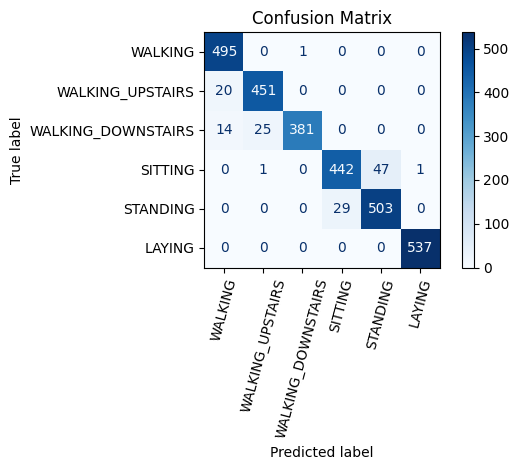

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_labels["activity_name"].tolist())
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## PCA analysis

In [16]:
pca = PCA(n_components=0.99)
X_train_s_pca = pca.fit_transform(X_train_s)
X_val_s_pca = pca.transform(X_val_s)
X_test_s_pca = pca.transform(X_test_s)

In [17]:
X_train_t_pca = torch.tensor(X_train_s_pca, dtype=torch.float32)
y_train_t_pca = torch.tensor(y_train, dtype=torch.long)

X_val_t_pca = torch.tensor(X_val_s_pca, dtype=torch.float32)
y_val_t_pca = torch.tensor(y_val, dtype=torch.long)

X_test_t_pca = torch.tensor(X_test_s_pca, dtype=torch.float32)
y_test_t_pca = torch.tensor(y_test_enc, dtype=torch.long)

In [19]:
best_model_pca, best_params_pca, best_score_pca, results_pca = MLPClassifier.grid_search_mlp(
    X_train_t_pca, y_train_t_pca,
    X_val_t_pca, y_val_t_pca,
    input_dim=X_train_t_pca.shape[1],
    num_classes=len(torch.unique(y_train_t_pca)),
    param_grid=param_grid
)

print("\nBest Params:", best_params_pca)
print("Best Validation Accuracy:", best_score_pca)


Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 32, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 32, 'epochs': 15} --> Best Val Acc = 0.9873

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 64, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 64, 'epochs': 15} --> Best Val Acc = 0.9891

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 128, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 128, 'epochs': 15} --> Best Val Acc = 0.9927

Testing: {'size': 'small', 'lr': 0.001, 'batch_size': 256, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.001, 'batch_size': 256, 'epochs': 15} --> Best Val Acc = 0.9882

Testing: {'size': 'small', 'lr': 0.0005, 'batch_size': 32, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.0005, 'batch_size': 32, 'epochs': 15} --> Best Val Acc = 0.9882

Testing: {'size': 'small', 'lr': 0.0005, 'batch_size': 64, 'epochs': 15}
Finished: {'size': 'small', 'lr': 0.0005, 'batch_size': 64, 

In [20]:
final_model_pca = MLPClassifier(
    input_dim=X_train_t_pca.shape[1],
    num_classes=len(torch.unique(y_train_t_pca)),
    size=best_params_pca["size"]
)

final_model_pca.fit(
    X_train_t_pca, y_train_t_pca,
    X_val_t_pca, y_val_t_pca,
    lr=best_params_pca["lr"],
    batch_size=best_params_pca["batch_size"],
    epochs=30
)

0.9909338168631007

In [21]:
y_pred_pca, y_true_pca, test_acc_pca = final_model_pca.evaluate(X_test_t_pca, y_test_t_pca)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision_score(y_true_pca, y_pred_pca, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_true_pca, y_pred_pca, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_true_pca, y_pred_pca, average='weighted'):.4f}")

Final Test Accuracy: 0.9532
Precision: 0.9553
Recall: 0.9545
F1-score: 0.9544


<Figure size 800x600 with 0 Axes>

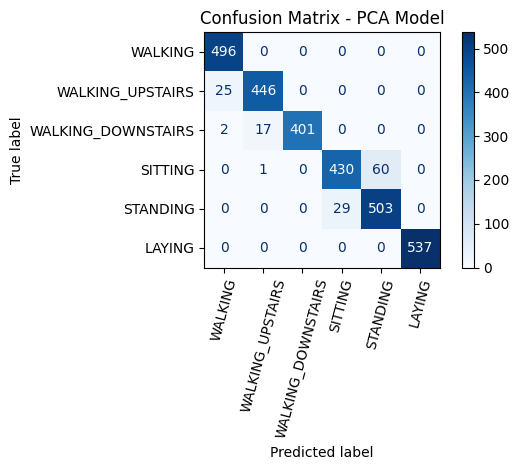

In [33]:
cm_pca = confusion_matrix(y_true_pca, y_pred_pca)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - PCA Model")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()